# Example 01: DFT normalizations and Parseval's theorem

This module provides four normalizations: **PSD** (power spectral density), **ASD** (amplitude spectral density), **ASD absolute**, and **CFT** (continuous Fourier transform). PSD and ASD are intended for stationary signals where total signal power is the quantity of interest, e.g. sensor noise and sensitivity analysis. CFT is intended for transient, decaying signals such as NMR free induction decays. 

*Implementation: `NormType` in [dft/config.py](../dftmodels/dft/config.py).*

## ASD / PSD normalization

The ASD normalization is defined so that Parseval's theorem holds:

$$
\int |X_\text{ASD}(f)|^2 \, df = \int X_\text{PSD}(f) \, df = \text{RMS}^2
$$

The normalization factor is:

$$
\text{norm}_\text{ASD} = \sqrt{\text{norm}_\text{PSD}} =
\begin{cases}
    \sqrt{2} \,/\, (\sqrt{sr \cdot N} \cdot w_\text{rms}) & \text{single-sided} \\
    1        \,/\, (\sqrt{sr \cdot N} \cdot w_\text{rms}) & \text{double-sided}
\end{cases}
$$

where $sr$ is the sample rate, $N$ the number of samples, and $w_\text{rms}$ the RMS of the window function. The $w_\text{rms}$ factor compensates for amplitude attenuation introduced by the window; omitting it leads to a systematic underestimate of the power by a factor of $w_\text{rms}^{-2}$.

This correction is exact only in the limit $N \to \infty$. For finite $N$, the effective RMS of the windowed signal depends on the alignment of the signal with the window shape, so the $w_\text{rms}$ correction is exact on average and the residual error decreases with $N$.

A data-dependent normalization that enforces Parseval's theorem exactly for any $N$ would instead define

$$
X_\text{ASD}(f) = X_\text{RAW}(f) \cdot \frac{\text{RMS}}{\sqrt{\int |X_\text{RAW}(f)|^2 \, df}}
$$

This is not used here for two reasons: (1) the normalization depends on the measurement data rather than solely on the DFT configuration, and (2) it is no longer self-consistent when applied to a subset of the original record.

*Implementation: `DFTConfig.norm_factor` in [dft/config.py](../dftmodels/dft/config.py).*

## Spectral integration

Throughout this notebook, $\int X(f)\,df$ is a notational shorthand for a weighted discrete sum over DFT bins, not a Riemann integral. The notation is intentional: a naive unweighted sum gives the wrong result for single-sided spectra, as explained below.

The exact definition is:

$$
\int X(f)\,df \;\equiv\; \Delta f \sum_k w_k \, X(f_k)
$$

with bin spacing $\Delta f = sr / N_\text{FFT}$. The weights $w_k$ depend on the spectrum type.

**Single-sided:** The single-sided normalization folds the two-sided spectrum onto the positive-frequency axis by applying a factor of $\sqrt{2}$ uniformly to all bins. DC ($f = 0$) and Nyquist ($f = sr/2$) are real-valued and self-conjugate; they contribute power only once in the two-sided spectrum and are therefore overcounted by this uniform factor. The correct weights are $w_0 = w_{N/2} = 1/2$ for DC and Nyquist, and $w_k = 1$ for all interior bins. A naive sum with $w_k = 1$ uniformly overestimates the total power by one half-bin at each endpoint.

**Double-sided:** $w_k = 1$ for all bins.

When integrating over a sub-band $[f_\text{min}, f_\text{max}]$, boundary bins are weighted by their fractional overlap with the interval. Setting $f_\text{min} = 0$, $f_\text{max} = sr/2$ explicitly for a single-sided spectrum reproduces the full-band weights above.

*Implementation: `FourierSeries.calculate_integral()` in [dft/series.py](../dftmodels/dft/series.py).*

## CFT normalization

For decaying signals, ASD and PSD are not meaningful because the power depends on acquisition length. The CFT normalization satisfies:

$$
\int X_\text{CFT}(f)\,df = x(0)
$$

so the spectrum integrates to the initial amplitude of the signal, independent of record length. This is verified in Example 04.

*Implementation: `DFTConfig.norm_factor` in [dft/config.py](../dftmodels/dft/config.py).*

## Example signals

The spectral comparison uses two signal types at three acquisition lengths (2 s, 5 s, 10 s):

- Static sinusoid: $x(t) = A\cos(2\pi f_0 t)$, $A = \sqrt{2}$ V, $\text{RMS} = A/\sqrt{2} = 1$ V.
- Decaying sinusoid: $x(t) = A\,e^{-\gamma t}\cos(2\pi f_0 t)$, $A = 15$ V, $\gamma = 3\,\text{s}^{-1}$.

The two groups are placed at different center frequencies (8–12 Hz and 18–22 Hz) to prevent peak overlap in the spectral comparison plot. The amplitudes are chosen such that both signal types produce peaks of comparable height in the ASD spectra: $A_\text{decay} = 15$ V is much larger than $A_\text{static} = \sqrt{2}$ V, but the exponential decay reduces the effective RMS over any finite record length, bringing it into a similar range as $\text{RMS}_\text{static} = 1$ V.

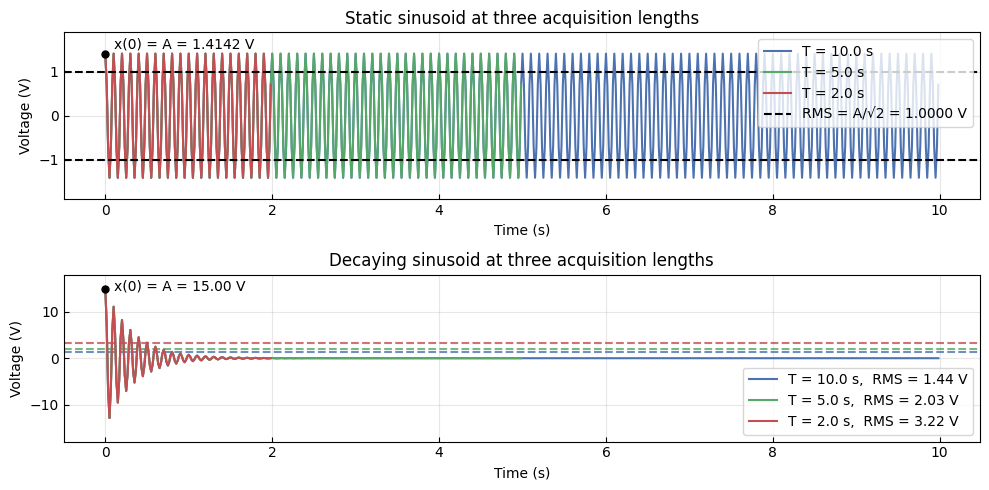

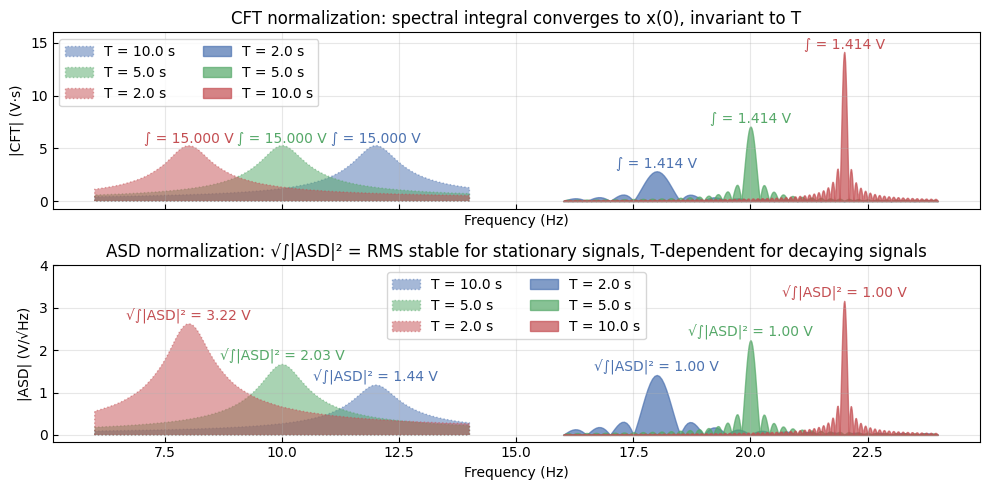

In [1]:
# Imports, constants, time-domain signal overview
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Path("figures").mkdir(exist_ok=True)
plt.style.use("dftmodels.mplstyle")

from dftmodels import SignalSeries, NormType, WindowType, DFTRange, Sinusoid

SAMPLE_RATE = 60.0
A_DECAY     = 15.0     # V  →  x(0) = A (pure cosine, zero phase)
A_STATIC    = np.sqrt(2)     # V  →  x(0) = A (pure cosine, zero phase)
F0          = 10.0
F_DECAYS    = [8.0, 10., 12.]   # Hz
F_STATICS   = [18., 20., 22.]   # Hz
GAMMA       = 3.0     # 1/s →  time constant 1/γ ≈ 0.33 s

PAD    = 10.0
WINDOW = WindowType.RECTANGULAR

DURATIONS = [2.0, 5.0, 10.0]

# --- Time-domain overview ---
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=False)

for i, T in enumerate(DURATIONS[::-1]):
    n = int(SAMPLE_RATE * T)
    t = np.arange(n) / SAMPLE_RATE
    y = Sinusoid.eval(t, A_STATIC, 0.0, F0)
    axes[0].plot(t, y, c=f"C{i}", label=f"T = {T} s")

rms_static = A_STATIC / np.sqrt(2)
axes[0].axhline( rms_static, ls="--", color="k", label=f"RMS = A/√2 = {rms_static:.4f} V")
axes[0].axhline(-rms_static, ls="--", color="k",)
axes[0].plot(0, A_STATIC, marker='o', color='k', ms=5, clip_on=False, zorder=5)
axes[0].text(0.1, A_STATIC + 0.06, f"x(0) = A = {A_STATIC:.4f} V", va='bottom')

for i, T in enumerate(DURATIONS[::-1]):
    n = int(SAMPLE_RATE * T)
    t = np.arange(n) / SAMPLE_RATE
    y = Sinusoid.eval(t, A_DECAY, 0.0, F0, GAMMA)
    rms_decay = np.sqrt(np.mean(y**2))
    axes[1].plot(t, y, c=f"C{i}", label=f"T = {T} s,  RMS = {rms_decay:.2f} V")
    axes[1].axhline(rms_decay, ls="--", color=f"C{i}", alpha=0.8)

axes[1].plot(0, A_DECAY, marker='o', color='k', ms=5, clip_on=False, zorder=5)
axes[1].text(0.1, A_DECAY + 0.4, f"x(0) = A = {A_DECAY:.2f} V", va='center')

axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title("Static sinusoid at three acquisition lengths")
axes[0].legend()
axes[0].set_ylim(bottom=-1.9, top=1.9)

axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Voltage (V)")
axes[1].set_title("Decaying sinusoid at three acquisition lengths")
axes[1].legend()
axes[1].set_ylim(bottom=-18.0,top=18.0)

plt.tight_layout()
plt.savefig(f"figures/01_dft_normalization_fig00.svg", bbox_inches="tight")
plt.show()

# --- Spectral comparison: CFT vs ASD ---
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex="all")

cft_integrals = []
asd_integrals = []

for i, (T, F_DECAY) in enumerate(zip(DURATIONS[::-1], F_DECAYS[::-1])):
    n = int(SAMPLE_RATE * T)
    t = np.arange(n) / SAMPLE_RATE
    y = Sinusoid.eval(t, A_DECAY, 0.0, F_DECAY, GAMMA)
    sig = SignalSeries(x=t, y=y)

    dft_cft = sig.calculate_dft(
        norm=NormType.CFT, window=WINDOW,
        dft_range=DFTRange.SINGLE_SIDED, pad=PAD,
    )
    dft_asd = sig.calculate_dft(
        norm=NormType.ASD, window=WINDOW,
        dft_range=DFTRange.SINGLE_SIDED, pad=PAD,
    )

    md = (6. <= dft_cft.x) & (dft_cft.x <= 14.)

    cft_integrals.append(float(np.real(dft_cft.calculate_integral())))
    asd_integrals.append(float(np.sqrt(dft_asd.convert_to_psd().calculate_integral())))

    axes[0].fill_between(dft_cft.x[md], dft_cft.abs.y[md], alpha=0.5,
                         label=f"T = {T} s", ls=":", color=f"C{i}")
    axes[1].fill_between(dft_asd.x[md], dft_asd.abs.y[md], alpha=0.5,
                         label=f"T = {T} s", ls=":", color=f"C{i}")

    pk = np.argmax(dft_cft.abs.y[md])
    axes[0].text(dft_cft.x[md][pk], dft_cft.abs.y[md][pk],
                 f"∫ = {cft_integrals[-1]:.3f} V",
                 ha='center', va='bottom', color=f"C{i}")

    pk = np.argmax(dft_asd.abs.y[md])
    axes[1].text(dft_asd.x[md][pk], dft_asd.abs.y[md][pk],
                 f"√∫|ASD|² = {asd_integrals[-1]:.2f} V",
                 ha='center', va='bottom', color=f"C{i}")

cft_integrals = []
asd_integrals = []

for i, (T, F_STATIC) in enumerate(zip(DURATIONS, F_STATICS)):
    n = int(SAMPLE_RATE * T)
    t = np.arange(n) / SAMPLE_RATE
    y = Sinusoid.eval(t, A_STATIC, 0.0, F_STATIC)
    sig = SignalSeries(x=t, y=y)

    dft_cft = sig.calculate_dft(
        norm=NormType.CFT, window=WINDOW,
        dft_range=DFTRange.SINGLE_SIDED, pad=PAD,
    )
    dft_asd = sig.calculate_dft(
        norm=NormType.ASD, window=WINDOW,
        dft_range=DFTRange.SINGLE_SIDED, pad=PAD
    )
    ms = (16. <= dft_cft.x) & (dft_cft.x <= 24.)

    cft_integrals.append(float(np.real(dft_cft.calculate_integral())))
    asd_integrals.append(float(np.sqrt(dft_asd.convert_to_psd().calculate_integral())))

    axes[0].fill_between(dft_cft.x[ms], dft_cft.abs.y[ms], alpha=0.7,
                         label=f"T = {T} s", color=f"C{i}")
    axes[1].fill_between(dft_asd.x[ms], dft_asd.abs.y[ms], alpha=0.7,
                         label=f"T = {T} s", color=f"C{i}")

    pk = np.argmax(dft_cft.abs.y[ms])
    axes[0].text(dft_cft.x[ms][pk], dft_cft.abs.y[ms][pk],
                 f"∫ = {cft_integrals[-1]:.3f} V",
                 ha='center', va='bottom', color=f"C{i}")

    pk = np.argmax(dft_asd.abs.y[ms])
    axes[1].text(dft_asd.x[ms][pk], dft_asd.abs.y[ms][pk],
                 f"√∫|ASD|² = {asd_integrals[-1]:.2f} V",
                 ha='center', va='bottom', color=f"C{i}")

axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("|CFT| (V·s)")
axes[0].set_title("CFT normalization: spectral integral converges to x(0), invariant to T")
axes[0].legend(ncol=2)
axes[0].set_ylim(top=16.0)

axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("|ASD| (V/√Hz)")
axes[1].set_title("ASD normalization: √∫|ASD|² = RMS stable for stationary signals, T-dependent for decaying signals")
axes[1].legend(ncol=2)
axes[1].set_ylim(top=4.0)

plt.tight_layout()
plt.savefig(f"figures/01_dft_normalization_fig01.svg", bbox_inches="tight")
plt.show()


## DFT parameter independence

The figure shows ASD spectra for seven combinations of window function, zero-padding factor, and acquisition length. ASD is used as the representative case; the identity $\int|\text{ASD}|^2\,df = \text{RMS}^2$ follows from the weighted discrete sum definition in the introduction and holds for all normalizations. Each annotated value should equal $A^2/2 = 2\,\text{V}^2$.

Different windows shape the spectral peak: Flat-Top spreads power across a wide main lobe for accurate amplitude estimation; Hamming/Hann/Blackman concentrate it more tightly. Regardless of window shape, total power is preserved.

The noise floor $\sigma\sqrt{2/sr}$ is independent of acquisition length: a longer record narrows each bin and reduces variance but does not shift the level.

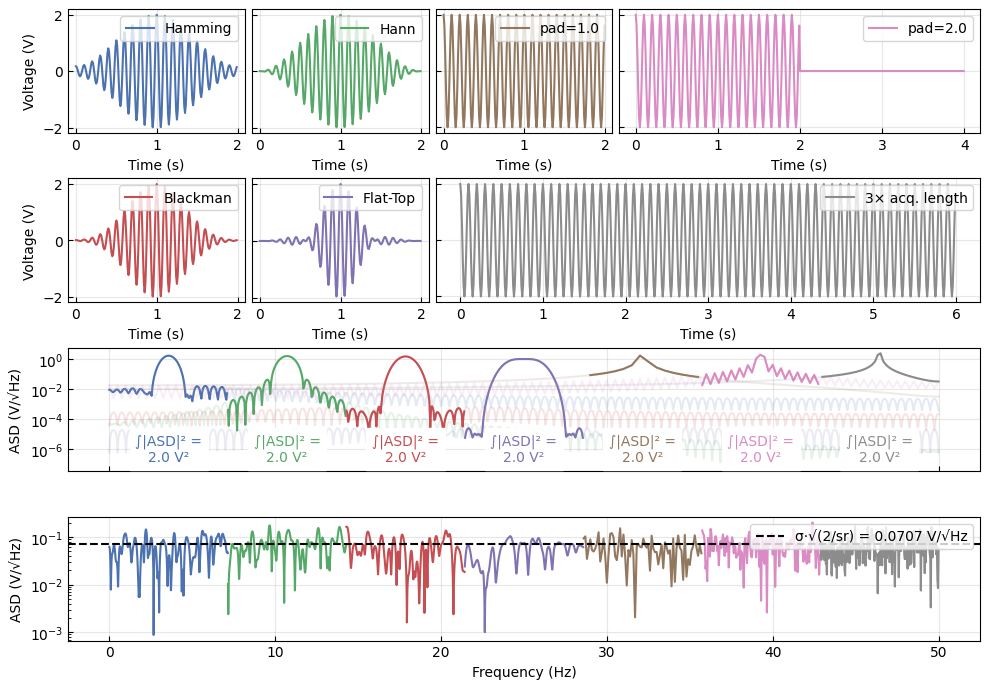

In [2]:
# ASD power invariance across windows, padding, and acquisition lengths
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("dftmodels.mplstyle")

from dftmodels import SignalSeries, NormType, WindowType, DFTRange, Sinusoid

SAMPLE_RATE  = 100.0   # Hz
AMPLITUDE    = 2.0     # V
N_BASE       = int(SAMPLE_RATE * 2.0)   # samples in base segment (2 s)
N_NOISE_BASE = 1_000                    # samples in base noise segment (10 s)
NOISE_RMS    = 0.5     # V
N_PANELS     = 7

rng = np.random.default_rng(seed=0)

# ---------------------------------------------------------------------------
# Panel definitions — each panel maps to one time-domain subplot (rows 0–1),
# one ASD peak trace (row 2), and one noise trace (row 3).
# ---------------------------------------------------------------------------
PANELS = [
    dict(window=WindowType.HAMMING,     pad=10.0, n_sig=N_BASE,       n_noise=N_NOISE_BASE,   label="Hamming",        show_padding=False),
    dict(window=WindowType.HANN,        pad=10.0, n_sig=N_BASE,       n_noise=N_NOISE_BASE,   label="Hann",           show_padding=False),
    dict(window=WindowType.BLACKMAN,    pad=10.0, n_sig=N_BASE,       n_noise=N_NOISE_BASE,   label="Blackman",       show_padding=False),
    dict(window=WindowType.FLAT_TOP,    pad=10.0, n_sig=N_BASE,       n_noise=N_NOISE_BASE,   label="Flat-Top",       show_padding=False),
    dict(window=WindowType.RECTANGULAR, pad=1.0,  n_sig=N_BASE,       n_noise=N_NOISE_BASE,   label="pad=1.0",        show_padding=False),
    dict(window=WindowType.RECTANGULAR, pad=2.0,  n_sig=N_BASE,       n_noise=N_NOISE_BASE,   label="pad=2.0",        show_padding=True),
    dict(window=WindowType.RECTANGULAR, pad=1.0,  n_sig=3 * N_BASE,   n_noise=3*N_NOISE_BASE, label="3× acq. length", show_padding=False),
]

# Time-domain subplot positions: (row, col, colspan)
SUBPLOT_LOCS = [
    ((0, 0), 1),
    ((0, 1), 1),
    ((1, 0), 1),
    ((1, 1), 1),
    ((0, 2), 1),
    ((0, 3), 2),
    ((1, 2), 3),
]

# ---------------------------------------------------------------------------
# Figure layout
# ---------------------------------------------------------------------------
plt.figure(figsize=(10, 7))

ax_peak = plt.subplot2grid(shape=(4, 5), loc=(2, 0), colspan=5)
ax_peak.semilogy()
ax_peak.set_ylabel("ASD (V/√Hz)")
ax_peak.tick_params(labelbottom=False)

ax_noise = plt.subplot2grid(shape=(4, 5), loc=(3, 0), colspan=5)
ax_noise.set_ylabel("ASD (V/√Hz)")
ax_noise.semilogy()
ax_noise.set_xlabel("Frequency (Hz)")


def plot_peak(asd, i):
    f_min    = i * SAMPLE_RATE / (2 * N_PANELS)
    f_center = (i + 0.5) * SAMPLE_RATE / (2 * N_PANELS)
    f_max    = (i + 1) * SAMPLE_RATE / (2 * N_PANELS)
    mask  = (f_min <= asd.x) & (asd.x <= f_max)

    ax_peak.plot(asd.x, asd.abs.y, c=f"C{i}", alpha=0.15)
    ax_peak.plot(asd.x[mask], asd.abs.y[mask], c=f"C{i}")

    label = f"∫|ASD|² =\n{float(asd.convert_to_psd().calculate_integral()):.1f} V²"
    
    ax_peak.text(
        x=f_center, y=1e-7, s=label,
        color=f"C{i}", backgroundcolor="white",
        horizontalalignment="center", verticalalignment="bottom",
    )


def plot_noise(asd, i):
    f_min = i * SAMPLE_RATE / (2 * N_PANELS)
    f_max = (i + 1) * SAMPLE_RATE / (2 * N_PANELS)
    mask  = (f_min <= asd.x) & (asd.x <= f_max)
    ax_noise.plot(asd.x[mask], asd.abs.y[mask], c=f"C{i}")


# ---------------------------------------------------------------------------
# Main loop — one pass per panel
# ---------------------------------------------------------------------------
for i, panel in enumerate(PANELS):
    n_sig, n_noise = panel["n_sig"], panel["n_noise"]

    # Build signal and noise
    t_sig  = np.linspace(0, n_sig / SAMPLE_RATE, n_sig, endpoint=False)
    f_sig  = (i + 0.5) * SAMPLE_RATE / (2 * N_PANELS)
    signal = SignalSeries(x=t_sig, y=Sinusoid.eval(t_sig, AMPLITUDE, 0.0, f_sig))

    t_noise = np.linspace(0, n_noise / SAMPLE_RATE, n_noise, endpoint=False)
    noise   = SignalSeries(x=t_noise, y=rng.normal(scale=NOISE_RMS, size=n_noise))

    # Compute spectra
    asd       = signal.calculate_dft(norm=NormType.ASD, window=panel["window"], pad=panel["pad"], dft_range=DFTRange.SINGLE_SIDED)
    asd_noise = noise.calculate_dft(norm=NormType.ASD,  window=panel["window"], pad=panel["pad"], dft_range=DFTRange.SINGLE_SIDED)

    # Time-domain subplot
    (row, col), colspan = SUBPLOT_LOCS[i]
    ax_td = plt.subplot2grid(shape=(4, 5), loc=(row, col), colspan=colspan)
    ax_td.set_xlabel("Time (s)")
    if col == 0:
        ax_td.set_ylabel("Voltage (V)")
    else:
        ax_td.tick_params(labelleft=False)

    windowed = Sinusoid.eval(t_sig, AMPLITUDE, 0.0, 10.0) * asd.dft_config.window_array
    if panel["show_padding"]:
        n_zeros = n_sig  # pad=2.0 → append one window-length of zeros
        t_plot  = np.linspace(0, (n_sig + n_zeros) / SAMPLE_RATE, n_sig + n_zeros, endpoint=False)
        y_plot  = np.concatenate([windowed, np.zeros(n_zeros)])
    else:
        t_plot, y_plot = t_sig, windowed
    ax_td.plot(t_plot, y_plot, c=f"C{i}", label=panel["label"])
    ax_td.legend(loc="upper right")

    plot_peak(asd, i)
    plot_noise(asd_noise, i)

# Predicted noise floor
floor = NOISE_RMS * np.sqrt(2.0 / SAMPLE_RATE)
ax_noise.axhline(floor, color="k", ls="--", label=f"σ·√(2/sr) = {floor:.4f} V/√Hz")
ax_noise.legend(loc="upper right")

plt.tight_layout(h_pad=0.5, w_pad=0.5)
plt.savefig(f"figures/01_dft_normalization_fig02.svg", bbox_inches="tight")
plt.show()

## Systematic check

The table below provides a numerical counterpart to the figure above, verifying $\int|\text{ASD}|^2\,df = \text{RMS}^2 = A^2/2$ for all combinations of window, padding factor, and DFT range using a long record ($N = 100{,}000$ samples, 1000 s at 100 Hz). Residual errors decrease with $N$ and are negligible for all parameter combinations at this record length. The Bartlett window shows errors roughly three orders of magnitude larger than the others (~$2\times10^{-9}$ V² vs. ~$5\times10^{-12}$ V²), consistent with the finite-$N$ sensitivity of the $w_\text{rms}$ correction discussed in the introduction.

In [3]:
# Systematic Parseval check across all windows, padding, and DFT ranges
SAMPLE_RATE = 100.0   # Hz
AMPLITUDE   = 2.0     # V
FREQUENCY   = 10.37   # Hz

N = int(SAMPLE_RATE * 1_000.0)
t = np.linspace(0, N / SAMPLE_RATE, N, endpoint=False)
y = Sinusoid.eval(t, AMPLITUDE, 0.0, FREQUENCY)
signal = SignalSeries(x=t, y=y)

true_rms   = AMPLITUDE / np.sqrt(2)   # exact for a pure cosine
true_power = true_rms ** 2

WINDOWS = [
    WindowType.RECTANGULAR,
    WindowType.HAMMING,
    WindowType.HANN,
    WindowType.BLACKMAN,
    WindowType.NUTTAL,
    WindowType.BLACKMAN_NUTTAL,
    WindowType.FLAT_TOP,
    WindowType.BARTLETT,
]

print(f"True RMS   = A / sqrt(2) = {true_rms:.8f} V")
print(f"True power = RMS²        = {true_power:.8f} V²")
print()

hdr = f"{'Window':16}  {'Pad':>5}  {'Range':>13}  {'dftmodels (V²)':>14}  {'error':>11}"
print(hdr)
print("-" * len(hdr))

for window in WINDOWS:
    for pad in [1.0, 2.0, 4.0]:
        for dft_range in [DFTRange.SINGLE_SIDED, DFTRange.DOUBLE_SIDED]:

            asd = signal.calculate_dft(
                norm=NormType.ASD, window=window, pad=pad, dft_range=dft_range
            )
            power   = float(asd.convert_to_psd().calculate_integral())
            error   = abs(power - true_power)

            print(
                f"{window.value:16}  {pad:>5.1f}  {dft_range.value:>13}  "
                f"{power:>14.8f}  {error:>11.2e}"
            )
    print()

True RMS   = A / sqrt(2) = 1.41421356 V
True power = RMS²        = 2.00000000 V²

Window              Pad          Range  dftmodels (V²)        error
-------------------------------------------------------------------
rectangular         1.0   single_sided      2.00000000     2.44e-12
rectangular         1.0   double_sided      2.00000000     4.66e-12
rectangular         2.0   single_sided      2.00000000     4.66e-12
rectangular         2.0   double_sided      2.00000000     9.55e-12
rectangular         4.0   single_sided      2.00000000     9.55e-12
rectangular         4.0   double_sided      2.00000000     9.55e-12

hamming             1.0   single_sided      2.00000000     2.45e-12
hamming             1.0   double_sided      2.00000000     4.66e-12
hamming             2.0   single_sided      2.00000000     4.66e-12
hamming             2.0   double_sided      2.00000000     9.56e-12
hamming             4.0   single_sided      2.00000000     9.56e-12
hamming             4.0   double_

## Summary

- **Window choice affects peak shape** (sidelobe level, main lobe width) but not total power: the w_rms correction is correct on average, and $\int|\text{ASD}|^2\,df \approx \text{RMS}^2$ for every window, padding factor, and DFT range. The residual error depends on signal-window alignment and vanishes as $N$ grows.
- **Noise floor is acquisition-length invariant**: ASD $\approx \sigma\sqrt{2/sr}$ regardless of how long the signal is; longer acquisitions reduce variance but do not shift the level.
- For **transient (decaying) signals**, the CFT normalization is more appropriate, see Notebook 04.